This notebook is to generate a volume plot for the glucagon case study. The plot will be similar to the plot in the GPCRmd pocket viewer.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

/tmp/ipykernel_90781/1694139799.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Cryptic pocket 

In [36]:
file = "/home/alex/Documents/pocket_tool/data/gpcrmd_sims/glr_5ee7_apo/apo/pockets_dyn815_traj15876/pocket_10_volumes.csv"
output_dir = "/home/alex/Documents/pocket_tool/docs/figures/raw"

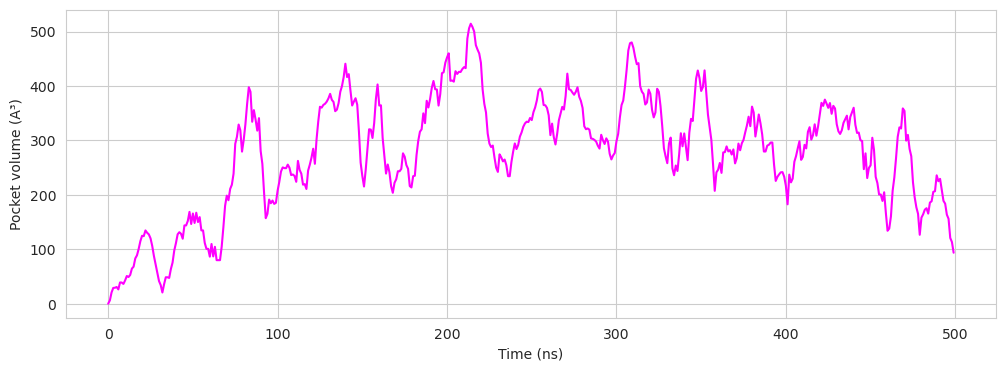

In [39]:
df = pd.read_csv(file, header=None)

# Smooth the data using a rolling mean
window_size = 10
df[0] = df[0].rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(12, 4))
sns.set_style("whitegrid")

sns.lineplot(data=df, x=df.index, y=0,color='magenta')
plt.xlabel('Time (ns)')
plt.ylabel('Pocket volume (A³)')

plt.savefig(os.path.join(output_dir, 'volume_vs_time_gln_815_15876.svg'))

### Cryptic subpocket

In [21]:
file = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/10_cryptic_subpocket/10714_trj_73.json"
output_dir = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/docs/figures/raw"

In [14]:
import json

json_content = json.load(open(file, 'r'))

POCKET_ID = 6
volumes = json_content['data'][POCKET_ID]['volumes']

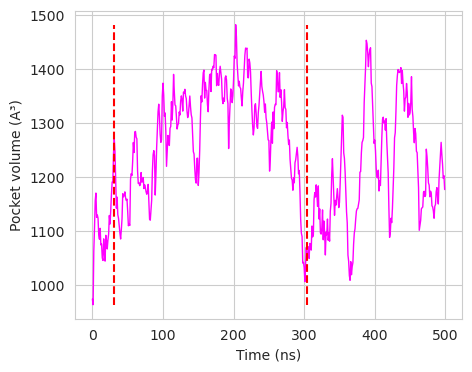

In [27]:
df = pd.DataFrame({'index': list(range(len(volumes))), 'volume': volumes})

# Smooth the data using a rolling mean
window_size = 10
df['volume'] = df['volume'].rolling(window=window_size, min_periods=1).mean()
plt.figure(figsize=(5, 4))
sns.set_style("whitegrid")

sns.lineplot(data=df, x=df.index, y='volume', color='magenta', linewidth=1)
plt.xlabel('Time (ns)')
plt.ylabel('Pocket volume (A³)')

plt.vlines(x=30, ymin=df['volume'].min(), ymax=df['volume'].max(), color='red', linestyle='--')
plt.vlines(x=304, ymin=df['volume'].min(), ymax=df['volume'].max(), color='red', linestyle='--')


plt.savefig(os.path.join(output_dir, 'volume_vs_time_oprd_73_10714.svg'))